# PaySim fraud detection — exploratory data analysis

This notebook **explores** the PaySim transaction dataset. We document data quality, label imbalance, and patterns that motivate later **preprocessing and modeling** (separate notebook).

**Dataset:** `PS_20174392719_1491204439457_log.csv` (same folder as this notebook).

**Target:** `isFraud` (1 = fraudulent, 0 = legitimate).

## 1. Setup and load

We load the CSV with pandas. Keep the working directory as the project folder so the filename resolves.

In [2]:
# Load PaySim transactions from CSV in this folder into a pandas DataFrame.
import pandas as pd
df = pd.read_csv("PS_20174392719_1491204439457_log.csv")


In [3]:
# Import plotting libraries, set pandas display options, random seed, and stratified plot sample size; print dataset shape.
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
PLOT_SAMPLE_N = 200_000  # stratified sample for heavy plots (adjust if needed)

print("Rows:", f"{len(df):,}", "| Columns:", df.shape[1])


Rows: 6,362,620 | Columns: 11


### 1.1 Schema: shape, names, types, peek

We confirm row/column counts, dtypes, and a few example rows before any analysis.

In [4]:
# Show dataset shape and preview the first rows (schema sanity check).
print("Shape:", df.shape)
df.head()


Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,"9,839.6400",C1231006815,"170,136.0000","160,296.3600",M1979787155,0.0000,0.0000,0,0
1,1,PAYMENT,"1,864.2800",C1666544295,"21,249.0000","19,384.7200",M2044282225,0.0000,0.0000,0,0
2,1,TRANSFER,181.0000,C1305486145,181.0000,0.0000,C553264065,0.0000,0.0000,1,0
3,1,CASH_OUT,181.0000,C840083671,181.0000,0.0000,C38997010,"21,182.0000",0.0000,1,0
4,1,PAYMENT,"11,668.1400",C2048537720,"41,554.0000","29,885.8600",M1230701703,0.0000,0.0000,0,0


In [5]:
# Print dtypes, non-null counts, and memory usage for all columns.
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [6]:
# List each column's dtype in a compact Series.
print(df.dtypes)


step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object


### 1.2 Target and feature groups

- **Target:** `isFraud`.
- **Numeric features:** `step`, `amount`, balance columns.
- **Categorical:** `type` (transaction category).
- **ID-like (high cardinality):** `nameOrig`, `nameDest` — usually not used as raw categorical dummies; may engineer aggregates later.
- **`isFlaggedFraud`:** business rule flag (large amounts). Treat as **separate** from the label; check for leakage before using as a model input.

In [7]:
# Classify columns into target, numeric, categorical, ID, and auxiliary label; build a feature summary table.
TARGET = "isFraud"

numeric_cols = ["step", "amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest"]
categorical_cols = ["type"]
id_cols = ["nameOrig", "nameDest"]
label_aux = ["isFlaggedFraud"]

feature_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "group": [
        "numeric" if c in numeric_cols else
        "categorical" if c in categorical_cols else
        "id" if c in id_cols else
        "target" if c == TARGET else
        "aux_label" if c in label_aux else
        "other"
        for c in df.columns
    ],
})
feature_summary


,column,dtype,group
0,step,int64,numeric
1,type,str,categorical
2,amount,float64,numeric
3,nameOrig,str,id
4,oldbalanceOrg,float64,numeric
5,newbalanceOrig,float64,numeric
6,nameDest,str,id
7,oldbalanceDest,float64,numeric
8,newbalanceDest,float64,numeric
9,isFraud,int64,target


## 2. Data quality

### 2.1 Missing values

PaySim is often clean; we still report null counts and percentages.

In [8]:
# Summarize missing value counts and percentage per column.
missing = df.isna().sum().rename("n_missing")
missing_pct = (missing / len(df) * 100).rename("pct_missing")
miss_df = pd.concat([missing, missing_pct], axis=1).sort_values("n_missing", ascending=False)
miss_df


,n_missing,pct_missing
step,0,0.0000
type,0,0.0000
amount,0,0.0000
nameOrig,0,0.0000
oldbalanceOrg,0,0.0000
newbalanceOrig,0,0.0000
nameDest,0,0.0000
oldbalanceDest,0,0.0000
newbalanceDest,0,0.0000
isFraud,0,0.0000


In [9]:
# Plot missing-value percentages by column if any exist; otherwise report none.
if miss_df["n_missing"].sum() > 0:
    plt.figure(figsize=(8, 4))
    miss_df[miss_df["n_missing"] > 0]["pct_missing"].plot(kind="barh")
    plt.xlabel("% missing")
    plt.title("Missing values by column")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values in any column.")


No missing values in any column.


### 2.2 Duplicate rows

Exact duplicates would inflate counts; we check how many full-row duplicates exist.

In [10]:
# Count exact duplicate rows and preview a few if duplicates exist.
dup_count = df.duplicated().sum()
print(f"Exact duplicate rows: {dup_count:,} ({dup_count / len(df) * 100:.4f}%)")
if dup_count > 0:
    display(df[df.duplicated(keep=False)].head(10))


Exact duplicate rows: 0 (0.0000%)


### 2.3 Basic value validity

We check for negative `amount`, impossible balance combinations where obvious, and valid `type` categories.

In [11]:
# Check negative amounts/balances and list transaction type frequencies.
neg_amount = (df["amount"] < 0).sum()
print(f"Rows with amount < 0: {neg_amount:,}")

bal_neg = ((df[numeric_cols] < 0).sum()).rename("n_negative")
print("Negative counts in numeric columns:")
print(bal_neg)

print("\nTransaction type value counts:")
print(df["type"].value_counts())


Rows with amount < 0: 0
Negative counts in numeric columns:
step              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
Name: n_negative, dtype: int64

Transaction type value counts:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


## 3. Target analysis (imbalance)

Fraud is rare; **accuracy** will be misleading. This motivates PR-AUC, recall/precision, cost-sensitive thresholds, and resampling/weights later.

In [12]:
# Tabulate fraud vs non-fraud counts and percentages.
vc = df[TARGET].value_counts().sort_index()
pct = df[TARGET].value_counts(normalize=True).sort_index() * 100
target_tbl = pd.DataFrame({"count": vc, "percent": pct})
target_tbl


,count,percent
isFraud,,
0,6354407,99.8709
1,8213,0.1291


Imbalance (majority / minority): 773.7 : 1


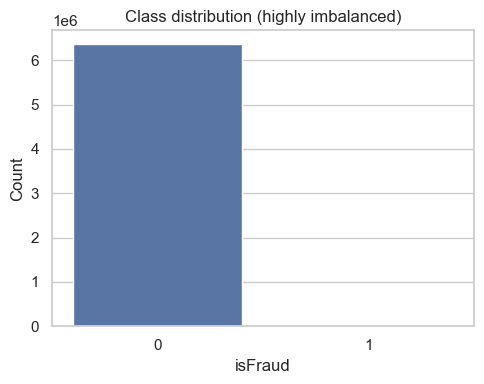

In [13]:
# Compute majority-to-minority imbalance ratio and plot the class distribution.
maj, minr = target_tbl["count"].max(), target_tbl["count"].min()
imbalance_ratio = maj / minr
print(f"Imbalance (majority / minority): {imbalance_ratio:,.1f} : 1")

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=target_tbl.index.astype(str), y=target_tbl["count"], ax=ax)
ax.set_xlabel("isFraud")
ax.set_ylabel("Count")
ax.set_title("Class distribution (highly imbalanced)")
plt.tight_layout()
plt.show()


## 4. Univariate EDA

### 4.1 Numeric summaries

Full-data descriptive statistics for core numerics (cheap on this width).

In [14]:
# Descriptive statistics (with extra percentiles) for core numeric columns.
df[numeric_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
count,"6,362,620.0000","6,362,620.0000","6,362,620.0000","6,362,620.0000","6,362,620.0000","6,362,620.0000"
mean,243.3972,"179,861.9035","833,883.1041","855,113.6686","1,100,701.6665","1,224,996.3982"
std,142.3320,"603,858.2315","2,888,242.6730","2,924,048.5030","3,399,180.1130","3,674,128.9421"
min,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1%,9.0000,449.4676,0.0000,0.0000,0.0000,0.0000
5%,16.0000,"2,224.0995",0.0000,0.0000,0.0000,0.0000
50%,239.0000,"74,871.9400","14,208.0000",0.0000,"132,705.6650","214,661.4400"
95%,490.0000,"518,634.1965","5,823,702.2785","5,980,262.3365","5,147,229.7135","5,515,715.9035"
99%,681.0000,"1,615,979.4716","16,027,256.1337","16,176,160.5580","12,371,819.1548","13,137,866.9410"
max,743.0000,"92,445,516.6400","59,585,040.3700","49,585,040.3700","356,015,889.3500","356,179,278.9200"


### 4.2 Distributions (sampled plots)

Histograms on millions of rows are slow and redundant; we plot a **stratified random sample** so both classes appear. This still supports conclusions about skew (especially `amount`).

In [15]:
# Build a stratified random sample for plotting so both fraud classes appear.
def stratified_sample(frame, col, n_per_class, random_state=RANDOM_STATE):
    parts = []
    for y in frame[col].unique():
        sub = frame[frame[col] == y]
        take = min(n_per_class, len(sub))
        parts.append(sub.sample(take, random_state=random_state))
    return pd.concat(parts, axis=0).sample(frac=1, random_state=random_state)

n_each = PLOT_SAMPLE_N // 2
plot_df = stratified_sample(df, TARGET, n_each)
print("Plot sample size:", len(plot_df), "| fraud:", plot_df[TARGET].sum())


Plot sample size: 108213 | fraud: 8213


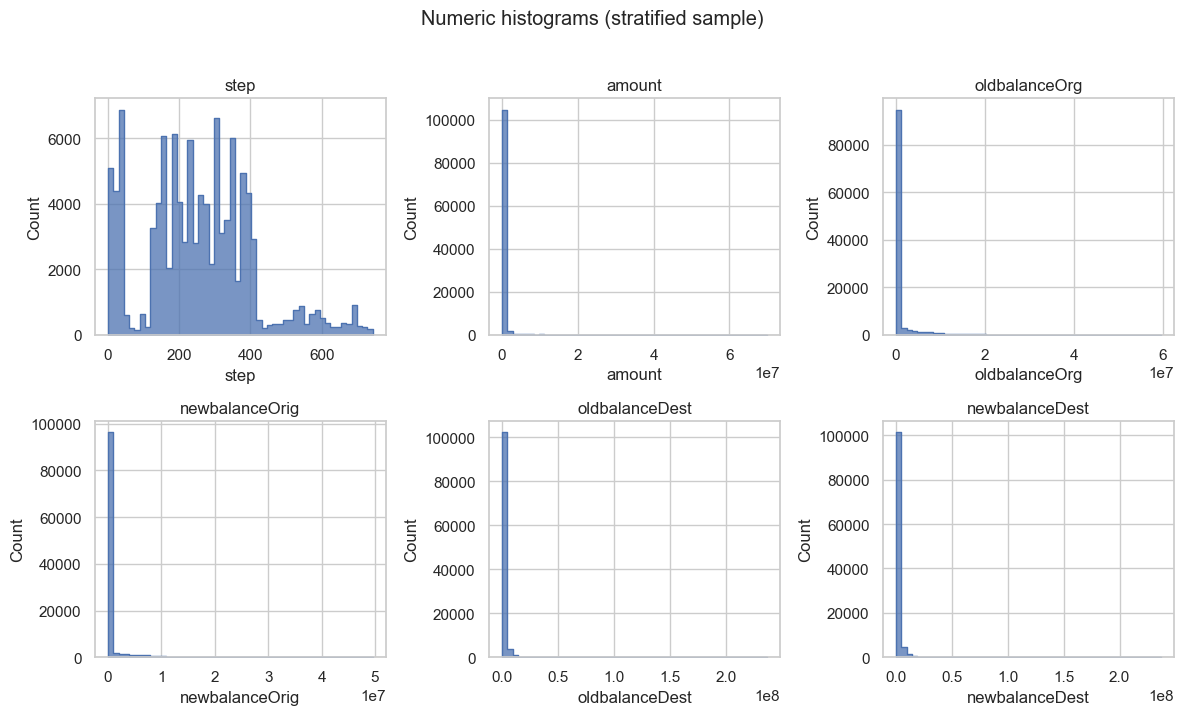

In [16]:
# Histograms of numeric features on the stratified sample (univariate shapes / skew).
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.ravel()
for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=plot_df, x=col, bins=50, ax=ax, element="step")
    ax.set_title(col)
plt.suptitle("Numeric histograms (stratified sample)", y=1.02)
plt.tight_layout()
plt.show()


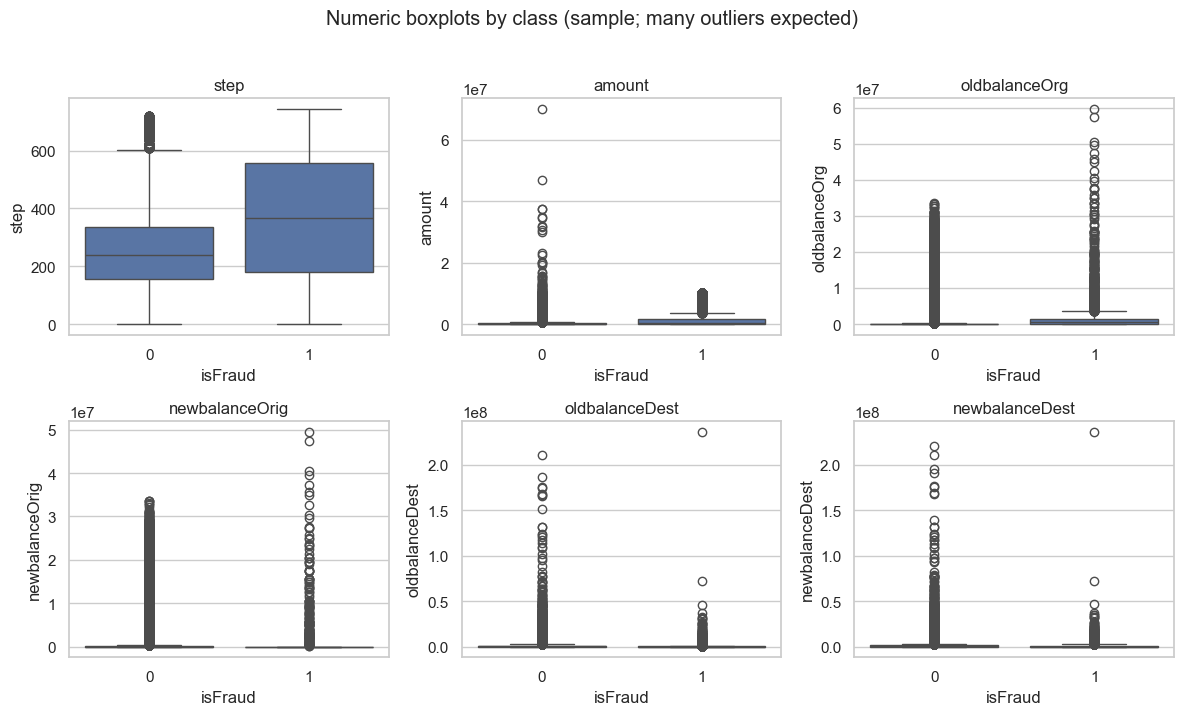

In [17]:
# Boxplots of numeric features by fraud label on the stratified sample.
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.ravel()
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=plot_df, y=col, x=plot_df[TARGET].astype(str), ax=ax)
    ax.set_title(col)
    ax.set_xlabel("isFraud")
plt.suptitle("Numeric boxplots by class (sample; many outliers expected)", y=1.02)
plt.tight_layout()
plt.show()


### 4.3 Transaction `type` frequency

Univariate view of the main categorical feature.

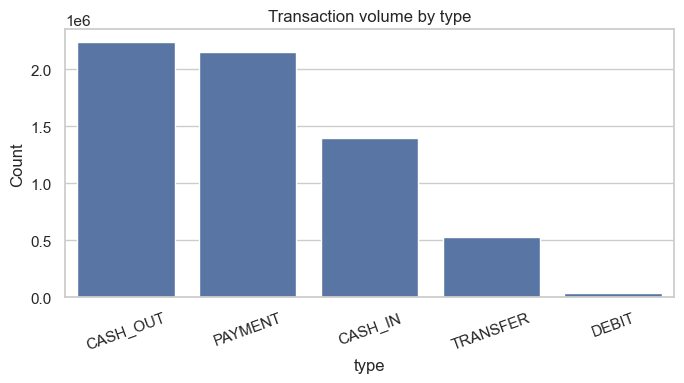

In [18]:
# Bar chart of transaction counts by type (univariate categorical).
type_counts = df["type"].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=type_counts.index, y=type_counts.values, ax=ax)
ax.set_ylabel("Count")
ax.set_xlabel("type")
ax.set_title("Transaction volume by type")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 5. Bivariate EDA — fraud vs features

### 5.1 Fraud rate by transaction type

Computed on **full data** (groupby is efficient). Fraud often concentrates in specific types in PaySim-like data.

In [19]:
# Aggregate fraud count and fraud rate by transaction type (full data).
fraud_by_type = (
    df.groupby("type", observed=False)
    .agg(n=(TARGET, "size"), frauds=(TARGET, "sum"))
    .assign(fraud_rate=lambda x: x["frauds"] / x["n"] * 100)
    .sort_values("fraud_rate", ascending=False)
)
fraud_by_type


,n,frauds,fraud_rate
type,,,
TRANSFER,532909,4097,0.7688
CASH_OUT,2237500,4116,0.1840
CASH_IN,1399284,0,0.0000
DEBIT,41432,0,0.0000
PAYMENT,2151495,0,0.0000


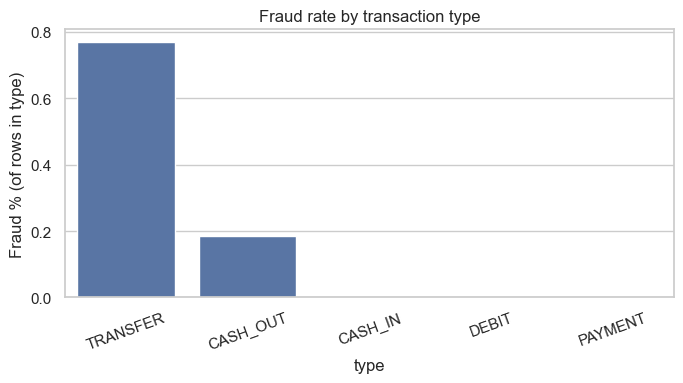

In [20]:
# Bar chart of fraud rate by transaction type.
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=fraud_by_type.index, y=fraud_by_type["fraud_rate"], ax=ax)
ax.set_ylabel("Fraud % (of rows in type)")
ax.set_xlabel("type")
ax.set_title("Fraud rate by transaction type")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### 5.2 Key numerics by class (sample)

Boxplots of numeric features by `isFraud` on the stratified sample `plot_df` are in **section 4.2** above. **Takeaway:** compare medians and spread; heavy tails mean robust scaling or tree models may behave differently than linear models.


### 5.3 Fraud over time (`step`)

`step` is a simulated time unit (1 step = 1 hour in PaySim documentation). We aggregate counts and fraud rate per step on the **full** dataset.

In [21]:
# Aggregate transaction volume, fraud count, and fraud rate by time step.
step_agg = (
    df.groupby("step")
    .agg(transactions=(TARGET, "size"), frauds=(TARGET, "sum"))
    .assign(fraud_rate=lambda x: x["frauds"] / x["transactions"] * 100)
)
step_agg.head()


,transactions,frauds,fraud_rate
step,,,
1,2708,16,0.5908
2,1014,8,0.7890
3,552,4,0.7246
4,565,10,1.7699
5,665,6,0.9023


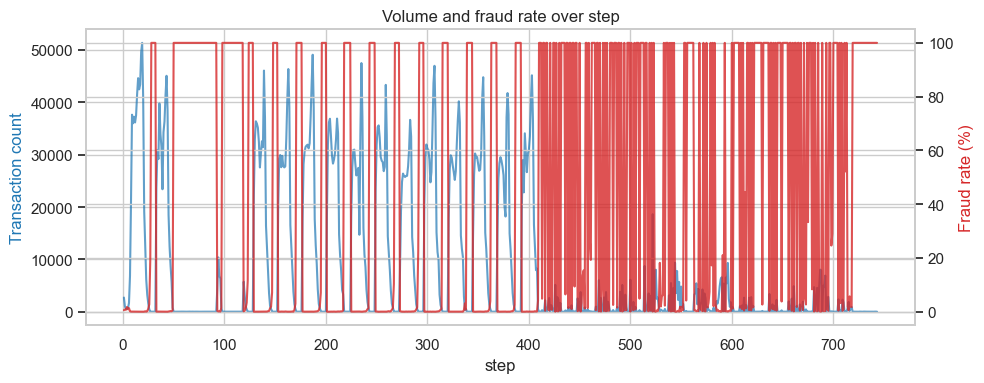

In [22]:
# Line plot of transaction volume and fraud rate over step.
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(step_agg.index, step_agg["transactions"], color="tab:blue", alpha=0.7, label="Transactions")
ax1.set_xlabel("step")
ax1.set_ylabel("Transaction count", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(step_agg.index, step_agg["fraud_rate"], color="tab:red", alpha=0.8, label="Fraud rate %")
ax2.set_ylabel("Fraud rate (%)", color="tab:red")
ax1.set_title("Volume and fraud rate over step")
fig.tight_layout()
plt.show()


## 6. Fraud-oriented patterns — balances

### 6.1 Balance consistency (engineered checks)

For many legitimate transfers, sender balance should decrease by about `amount`. We define simple discrepancy features and compare fraud vs non-fraud on a sample.

In [23]:
# Add balance delta/residual columns and summarize by fraud class on a sample.
bal = df.assign(
    orig_delta=df["oldbalanceOrg"] - df["newbalanceOrig"],
    dest_delta=df["newbalanceDest"] - df["oldbalanceDest"],
    orig_residual=(df["oldbalanceOrg"] - df["newbalanceOrig"]) - df["amount"],
)
bal_sample = stratified_sample(bal, TARGET, n_each)
bal_sample[[TARGET, "orig_residual", "orig_delta", "dest_delta"]].groupby(TARGET).describe(percentiles=[0.5, 0.9, 0.99])


orig_residual                                              \
                count          mean          std              min   
isFraud                                                             
0        100,000.0000 -203,481.8210 648,212.1273 -69,886,731.3000   
1          8,213.0000  -10,692.3253 265,146.1311 -10,000,000.0000   

                                            orig_delta                 \
                 50%    90%    99%    max        count           mean   
isFraud                                                                 
0       -68,794.9100 0.0000 0.0000 0.0100 100,000.0000   -22,964.8055   
1             0.0000 0.0000 0.0000 0.0000   8,213.0000 1,457,274.9739   

                                                                    \
                   std             min          50%            90%   
isFraud                                                              
0         106,155.1250 -1,225,177.3300       0.0000    33,287.2030   
1       2,396,099.2020          0.0000 436,317.4900 4,475,400.1720   

                                          dest_delta               \
                    99%             max        count         mean   
isFraud                                                             
0          209,982.7422  2,802,396.1900 100,000.0000 127,768.2836   
1       10,000,000.0000 10,000,000.0000   8,213.0000 735,457.9981   

                                                                              \
                   std             min    50%            90%             99%   
isFraud                                                                        
0         872,880.4000 -1,664,863.3200 0.0000   351,662.4340  1,792,825.7509   
1       1,856,983.8560   -315,226.0700 0.0000 2,054,275.5700 10,000,000.0000   

                         
                    max  
isFraud                  
0       82,704,592.2600  
1       14,915,111.4700

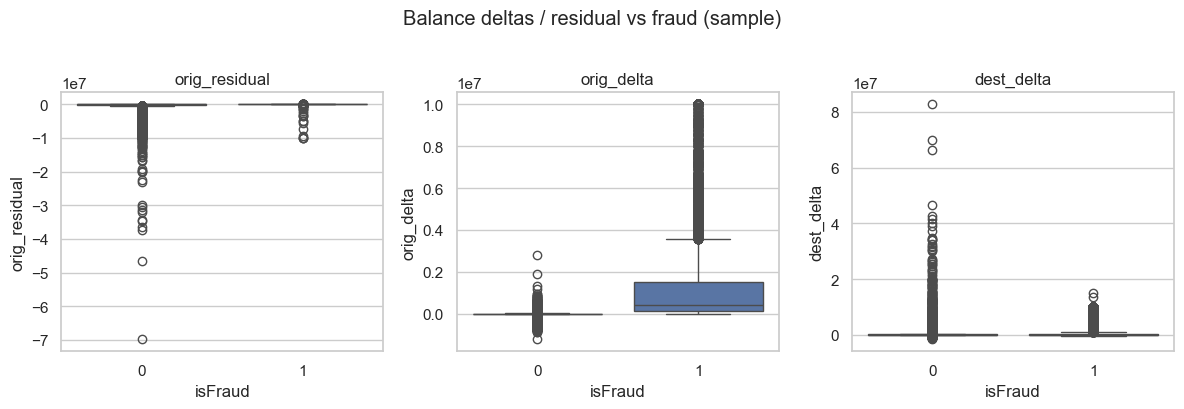

In [24]:
# Boxplots of balance deltas and residual by fraud class (sample).
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, ["orig_residual", "orig_delta", "dest_delta"]):
    sns.boxplot(data=bal_sample, x=bal_sample[TARGET].astype(str), y=col, ax=ax)
    ax.set_title(col)
plt.suptitle("Balance deltas / residual vs fraud (sample)", y=1.02)
plt.tight_layout()
plt.show()


### 6.2 Zero-balance flags (quick fraud rate tables)

We tabulate fraud prevalence when origin/destination balances are zero. Full-data groupby.

In [25]:
# Compare fraud rate for zero-balance flag combinations (full data).
flags = df.assign(
    orig_zero_old=df["oldbalanceOrg"] == 0,
    dest_zero_old=df["oldbalanceDest"] == 0,
    orig_zero_new=df["newbalanceOrig"] == 0,
    dest_zero_new=df["newbalanceDest"] == 0,
)
for c in ["orig_zero_old", "dest_zero_old", "orig_zero_new", "dest_zero_new"]:
    t = flags.groupby(c)[TARGET].mean() * 100
    print(c)
    print(t)
    print()


orig_zero_old
orig_zero_old
False   0.1918
True    0.0020
Name: isFraud, dtype: float64

dest_zero_old
dest_zero_old
False   0.0782
True    0.1979
Name: isFraud, dtype: float64

orig_zero_new
orig_zero_new
False   0.0058
True    0.2231
Name: isFraud, dtype: float64

dest_zero_new
dest_zero_new
False   0.1051
True    0.1677
Name: isFraud, dtype: float64



### 6.3 `amount` by fraud — log scale

Raw amounts are extremely skewed; log view matches the preprocessing idea (`log1p`).

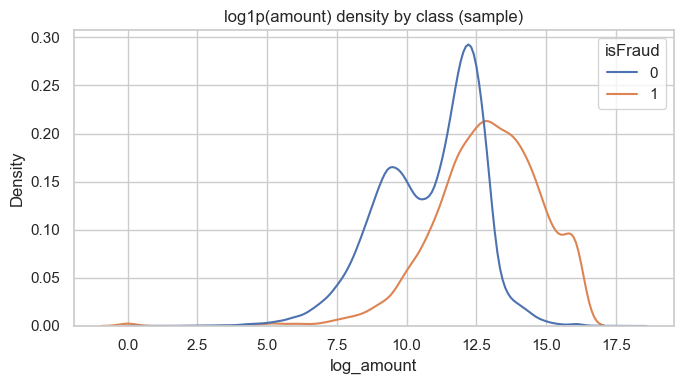

In [26]:
# KDE of log1p(amount) by fraud class on the stratified sample.
plot_df_log = plot_df.assign(log_amount=np.log1p(plot_df["amount"]))
fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(data=plot_df_log, x="log_amount", hue=plot_df_log[TARGET].astype(str), common_norm=False, ax=ax)
ax.set_title("log1p(amount) density by class (sample)")
plt.tight_layout()
plt.show()


## 7. Multivariate — correlation structure

Linear correlation among numerics (full data). Useful for redundancy (e.g., balances) before linear models; trees handle dependence differently.

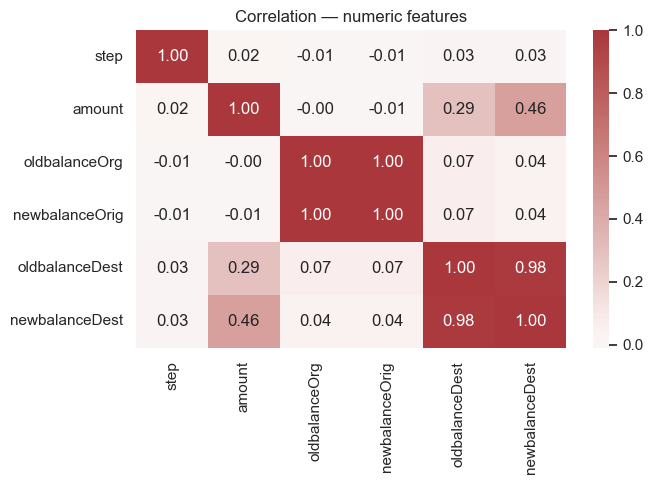

In [27]:
# Correlation heatmap for numeric features (full data).
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Correlation — numeric features")
plt.tight_layout()
plt.show()


### Optional: scatter on a small stratified sample (multivariate)

Joint view of two numerics with fraud highlighted — **do not** over-interpret from a sample; use for intuition only.

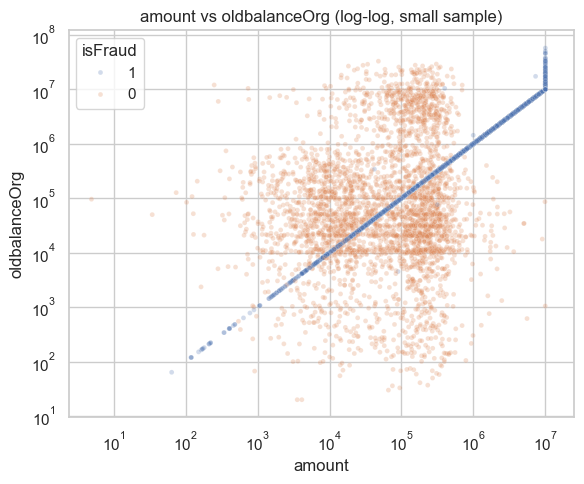

In [28]:
# Log-log scatter of amount vs oldbalanceOrg on a small stratified sample (multivariate glimpse).
scat = stratified_sample(df, TARGET, 5_000)
fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(
    data=scat,
    x="amount",
    y="oldbalanceOrg",
    hue=scat[TARGET].astype(str),
    alpha=0.25,
    s=12,
    ax=ax,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("amount vs oldbalanceOrg (log-log, small sample)")
plt.tight_layout()
plt.show()


## 8. Leakage and risky columns

### 8.1 `isFlaggedFraud`

This column flags very large transactions under a rule. It is **not** the same as `isFraud`, but it can be **highly aligned** with the label. Using it as a feature can inflate performance unrealistically or mimic label information. **Decision for modeling:** document whether we drop it, use it only as a baseline diagnostic, or keep it with justification.

In [29]:
# Cross-tabulate isFlaggedFraud vs isFraud to assess overlap.
pd.crosstab(df["isFlaggedFraud"], df[TARGET], margins=True)


isFraud,0,1,All
isFlaggedFraud,,,
0,6354407,8197,6362604
1,0,16,16
All,6354407,8213,6362620


In [30]:
# Print fraud rate when isFlaggedFraud is 1 vs 0.
print("Fraud rate when isFlaggedFraud == 1:", df.loc[df["isFlaggedFraud"] == 1, TARGET].mean() * 100, "%")
print("Fraud rate when isFlaggedFraud == 0:", df.loc[df["isFlaggedFraud"] == 0, TARGET].mean() * 100, "%")


Fraud rate when isFlaggedFraud == 1: 100.0 %
Fraud rate when isFlaggedFraud == 0: 0.12883090005287143 %


### 8.2 Post-transaction balances

In real-time fraud scoring, **post**-transaction balances may be unavailable at decision time or may be derived after the event. For this academic dataset, treat as **available features** but note the **operational** caveat in the report.

## 9. Preprocessing preview — `log1p(amount)`

Side-by-side view motivates the log transform planned in the proposal (actual scaling/encoding belongs in the preprocessing notebook).

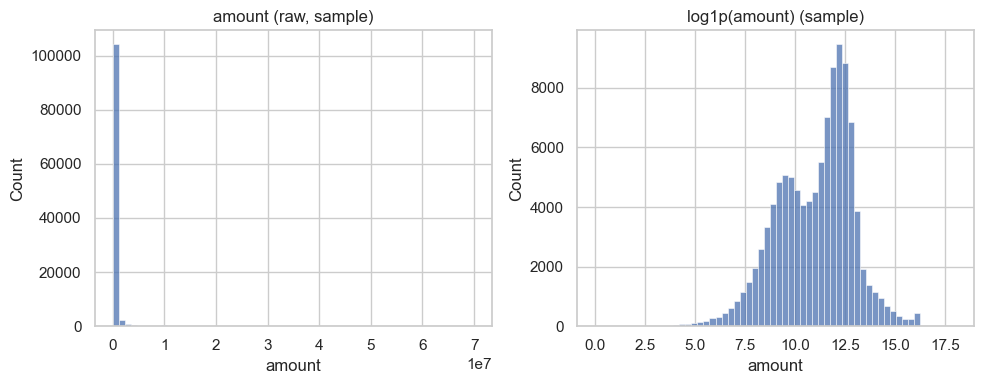

In [31]:
# Side-by-side histograms of raw amount and log1p(amount) on the sample (preprocessing motivation).
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(plot_df["amount"], bins=60, ax=axes[0])
axes[0].set_title("amount (raw, sample)")
sns.histplot(np.log1p(plot_df["amount"]), bins=60, ax=axes[1])
axes[1].set_title("log1p(amount) (sample)")
plt.tight_layout()
plt.show()


## 10. Key findings and feature action plan

**Key findings** (from this run of the notebook):

- **Scale:** 6,362,620 transactions and 11 columns; `df.info()` reports ~534 MB in memory.
- **Quality:** No missing values, no full-row duplicates, and no negative `amount` or negative values in the listed numeric columns.
- **Imbalance:** 6,354,407 legitimate (99.87%) vs 8,213 fraudulent (0.129%); majority-to-minority ratio **773.7 : 1**. Raw accuracy will be misleading; use PR-AUC, precision/recall, and cost-sensitive thresholds (as in the project proposal).
- **Fraud by `type`:** All frauds fall under **TRANSFER** (~0.77% of those rows) and **CASH_OUT** (~0.18%). **CASH_IN**, **DEBIT**, and **PAYMENT** show zero frauds here; `type` is a strong driver for modeling and interpretation.
- **Plot sample:** Stratified sample size is 108,213 rows (all 8,213 fraud cases plus a subsample of legitimate rows), limited by the minority class.
- **Balances:** Balance deltas, residuals, and zero-balance flags show materially different fraud rates; these motivate explicit features in preprocessing (see section 6).
- **`amount`:** Distributions are heavy-tailed; **log1p(`amount`)** is justified before linear or margin-based models (see section 9).
- **`isFlaggedFraud`:** When the flag equals 1, fraud rate is 100% but only **16** rows; when it equals 0, fraud rate is about **0.129%** with **8,197** frauds, so most fraud is not flagged by this rule. Using it as a feature risks leakage or inflated performance; document keep/drop in the report.
- **IDs:** `nameOrig` and `nameDest` are high-cardinality identifiers; drop for a simple tabular baseline or engineer aggregates later.

The table below summarizes a **preprocessing / modeling feature plan** derived from this EDA.


In [32]:
# Starter feature action table for preprocessing: keep/drop, dtypes, leakage notes.
feature_plan = pd.DataFrame([
    {"feature": "step", "dtype": "numeric", "preprocessing": "optional scaling for SVM/k-NN", "keep_drop": "keep", "leakage_risk": "low"},
    {"feature": "type", "dtype": "categorical", "preprocessing": "one-hot or target encoding", "keep_drop": "keep", "leakage_risk": "low"},
    {"feature": "amount", "dtype": "numeric", "preprocessing": "log1p + scale for linear/SVM", "keep_drop": "keep", "leakage_risk": "low"},
    {"feature": "oldbalanceOrg", "dtype": "numeric", "preprocessing": "scale / tree raw", "keep_drop": "keep", "leakage_risk": "low"},
    {"feature": "newbalanceOrig", "dtype": "numeric", "preprocessing": "scale / tree raw", "keep_drop": "keep", "leakage_risk": "note: post-tx"},
    {"feature": "oldbalanceDest", "dtype": "numeric", "preprocessing": "scale / tree raw", "keep_drop": "keep", "leakage_risk": "low"},
    {"feature": "newbalanceDest", "dtype": "numeric", "preprocessing": "scale / tree raw", "keep_drop": "keep", "leakage_risk": "note: post-tx"},
    {"feature": "nameOrig", "dtype": "id", "preprocessing": "drop for baseline or hash/aggregate", "keep_drop": "TBD", "leakage_risk": "low if no future info"},
    {"feature": "nameDest", "dtype": "id", "preprocessing": "drop for baseline or hash/aggregate", "keep_drop": "TBD", "leakage_risk": "low if no future info"},
    {"feature": "isFlaggedFraud", "dtype": "binary", "preprocessing": "often DROP as feature; analyze separately", "keep_drop": "TBD", "leakage_risk": "high / policy"},
])
feature_plan


,feature,dtype,preprocessing,keep_drop,leakage_risk
0,step,numeric,optional scaling for SVM/k-NN,keep,low
1,type,categorical,one-hot or target encoding,keep,low
2,amount,numeric,log1p + scale for linear/SVM,keep,low
3,oldbalanceOrg,numeric,scale / tree raw,keep,low
4,newbalanceOrig,numeric,scale / tree raw,keep,note: post-tx
5,oldbalanceDest,numeric,scale / tree raw,keep,low
6,newbalanceDest,numeric,scale / tree raw,keep,note: post-tx
7,nameOrig,id,drop for baseline or hash/aggregate,TBD,low if no future info
8,nameDest,id,drop for baseline or hash/aggregate,TBD,low if no future info
9,isFlaggedFraud,binary,often DROP as feature; analyze separately,TBD,high / policy


---

## Part II — Data preprocessing (continuation)

This section prepares **train/test splits** and a **reusable preprocessing pipeline** for modeling. It assumes you already ran the cells above so `df` and `RANDOM_STATE` exist.

**Evaluation artifacts:** **ROC curves** and **confusion matrices** are created **after** you train a model and produce predictions on validation or test data (or from cross-validation). They are not part of preprocessing.

**Rules:** stratified split first; fit encoders/scalers on **training data only**; apply the same fitted transformers to the test set; **SMOTE** (if used) only on the **training** portion, never on the test set.

### 11.1 Imports for preprocessing 

Install if needed: `pip install imbalanced-learn` (provides `imblearn`).

In [33]:
# Import scikit-learn utilities and SMOTE for imbalance handling (training data only).
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import joblib

# If this import fails, run: pip install imbalanced-learn
from imblearn.over_sampling import SMOTE


### 11.2 Build modeling table: target, drops, row-wise engineered features

We drop **ID** columns and **`isFlaggedFraud`** from the default feature matrix (leakage / policy risk; align with EDA). Row-wise engineered fields use **only that row’s values**, so they can be created **before** the split. We replace **`amount`** with **`log_amount = log1p(amount)`** per the project proposal.

In [34]:
# Copy df, add engineered columns, then build X (features) and y (target).
# Columns removed from X and why:
#   - isFraud          -> target y only (must not be a feature).
#   - amount           -> replaced by log_amount (proposal: log transform; avoid duplicate scale).
#   - nameOrig/nameDest-> high-cardinality IDs; one-hot not feasible; drop for baseline tabular models.
#   - isFlaggedFraud   -> business-rule flag; leakage / inflated metrics risk vs true fraud (see EDA); drop from default X.
TARGET = "isFraud"
DROP_FROM_X = ["nameOrig", "nameDest", "isFlaggedFraud"]

df_model = df.copy()
df_model["orig_delta"] = df_model["oldbalanceOrg"] - df_model["newbalanceOrig"]
df_model["dest_delta"] = df_model["newbalanceDest"] - df_model["oldbalanceDest"]
df_model["orig_residual"] = df_model["orig_delta"] - df_model["amount"]
df_model["orig_zero_old"] = (df_model["oldbalanceOrg"] == 0).astype(np.int8)
df_model["dest_zero_old"] = (df_model["oldbalanceDest"] == 0).astype(np.int8)
df_model["orig_zero_new"] = (df_model["newbalanceOrig"] == 0).astype(np.int8)
df_model["dest_zero_new"] = (df_model["newbalanceDest"] == 0).astype(np.int8)
df_model["log_amount"] = np.log1p(df_model["amount"].astype(np.float64))

y = df_model[TARGET].astype(np.int8)
X = df_model.drop(columns=[TARGET, "amount"] + DROP_FROM_X)
print("X shape:", X.shape, "| y shape:", y.shape, "| fraud rate:", y.mean() * 100, "%")


X shape: (6362620, 14) | y shape: (6362620,) | fraud rate: 0.12908204481801522 %


### 11.3 Stratified train/test split

Keeps the **fraud proportion** similar in train and test. **No** scaling or SMOTE before this step.

In [35]:
# Split features and target into train and test with stratification on isFraud.
TEST_SIZE = 0.2
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "fraud %:", y_train.mean() * 100)
print("Test: ", X_test.shape, "fraud %:", y_test.mean() * 100)

Train: (5090096, 14) fraud %: 0.12907418642005966
Test:  (1272524, 14) fraud %: 0.12911347840983745


### 11.4 Column transformer: scale numerics, one-hot `type`

**Fit on `X_train` only**; then transform train and test. This matches “split first, preprocess second.”

In [36]:
# Define numeric vs categorical columns and build a ColumnTransformer (fit on training only).
cat_features = ["type"]
num_features = [c for c in X_train.columns if c not in cat_features]

ohe_kwargs = {"handle_unknown": "ignore"}
try:
    ohe = OneHotEncoder(**ohe_kwargs, sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(**ohe_kwargs, sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", ohe, cat_features),
    ],
    remainder="drop",
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)
print("Processed train:", X_train_proc.shape, "| test:", X_test_proc.shape)

Processed train: (5090096, 18) | test: (1272524, 18)


### 11.5 Sanity checks (no leakage via test, no NaNs)

Confirm shapes, finite values, and that the **test** matrix was transformed with **fitted** parameters from train.

In [37]:
# Verify processed arrays are finite, aligned, and class balance is still extreme but stratified.
assert X_train_proc.shape[0] == len(y_train)
assert X_test_proc.shape[0] == len(y_test)
assert not np.isnan(X_train_proc).any()
assert not np.isnan(X_test_proc).any()
print("OK: shapes align, no NaNs in processed arrays.")

OK: shapes align, no NaNs in processed arrays.


### 11.6 SMOTE on **training** data only

We apply SMOTE only to **`X_train_proc`, `y_train`**. **Never** apply SMOTE to the test set. For cross-validation, the best practice is an `imblearn` pipeline so SMOTE runs **inside each fold** on training folds only (we can add that in the modeling section).

**Scale note:** We cap the target fraud count so SMOTE does not expand to millions of rows.


Before SMOTE: (5090096, 18) fraud %: 0.12907418642005966
After  SMOTE: (5108943, 18) fraud %: 0.4975001678429374


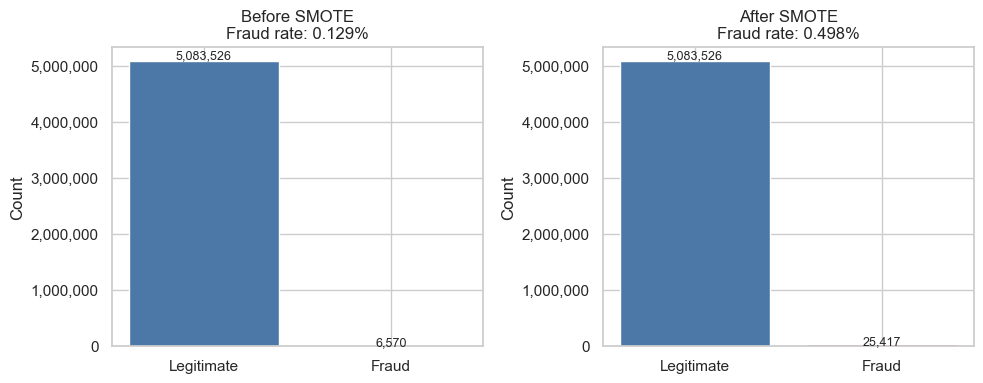

In [38]:
# Apply SMOTE on the processed training set only (never on test).
n_maj = int((y_train == 0).sum())
n_min = int(y_train.sum())

# Cap the target minority count to keep runtime/memory reasonable on PaySim.
target_minority = max(n_min, min(int(0.005 * n_maj), n_maj))
smote = SMOTE(random_state=RANDOM_STATE, sampling_strategy={1: target_minority})
X_train_smote, y_train_smote = smote.fit_resample(X_train_proc, y_train)
print("Before SMOTE:", X_train_proc.shape, "fraud %:", y_train.mean() * 100)
print("After  SMOTE:", X_train_smote.shape, "fraud %:", y_train_smote.mean() * 100)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (label, y) in zip(axes, [("Before SMOTE", y_train), ("After SMOTE", y_train_smote)]):
    counts = y.value_counts().sort_index()
    ax.bar(["Legitimate", "Fraud"], counts.values, color=["#4C78A8", "#E45756"])
    ax.set_title(f"{label}\nFraud rate: {y.mean()*100:.3f}%")
    ax.set_ylabel("Count")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
    for i, v in enumerate(counts.values):
        ax.text(i, v * 1.01, f"{v:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


### 11.7 Save preprocessing artifact (optional but recommended)

Saves the **fitted** `ColumnTransformer` next to this notebook so modeling code can `transform` new data the same way.

In [38]:
# Persist the fitted preprocessor with joblib for reproducibility in model training notebooks.
from pathlib import Path

_artifact_path = Path("preprocessor_paysim.joblib")
joblib.dump(preprocessor, _artifact_path)
print("Saved:", _artifact_path.resolve())

Saved: /Users/snehasingh/ML/Group_Project/preprocessor_paysim.joblib


### 11.8 What you have now (for the next section)

| Object | Use |
|--------|-----|
| `X_train_proc`, `X_test_proc` | Baseline training/evaluation (no SMOTE) |
| `y_train`, `y_test` | Labels aligned with the rows above |
| `X_train_smote`, `y_train_smote` | Training **only** when you want SMOTE-augmented learning |
| `preprocessor` | `transform` on any new `X` with the same columns as `X_train` |

**Next:** model training, then **ROC / PR curves**, **confusion matrices**, and cost-sensitive thresholds on **`X_test_proc`** (or CV).

---

## Part III - Model Training and Evaluation (Clean Final Section)

This section trains and compares **six experiments** on the same preprocessed train/test split from Part II.

### Experiments
- `logreg_plain`
- `logreg_class_weight`
- `logreg_smote`
- `rf_plain`
- `rf_class_weight`
- `rf_smote`

**Fairness rule:** all models are evaluated on the same untouched `X_test_proc`, `y_test`.


### 12.1 Imports and required object checks

We first verify that preprocessing outputs already exist, then import model/metric utilities.

In [39]:
# Import model and metric utilities and verify required preprocessed objects exist.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)

required_objects = ["X_train_proc", "X_test_proc", "y_train", "y_test", "X_train_smote", "y_train_smote"]
missing = [n for n in required_objects if n not in globals()]
if missing:
    raise ValueError(f"Missing preprocessing objects: {missing}")
print("OK: all required preprocessing objects exist.")
print("Train:", X_train_proc.shape, "| Test:", X_test_proc.shape)

# Hide noisy runtime warnings after numeric clipping/regularization; metrics still computed normally.
warnings.filterwarnings("ignore", category=RuntimeWarning)


OK: all required preprocessing objects exist.
Train: (5090096, 18) | Test: (1272524, 18)


### 12.2 Define the six experiments

We keep training setup consistent and only change imbalance strategy (plain / class weight / SMOTE).

In [40]:
# Define six experiments with readable groups and a fast mode to avoid long freezes during training.
RANDOM_STATE_MODEL = 42
FAST_MODE = True  # Set False for full final run once everything works.

if FAST_MODE:
    rf_n_estimators = 80
    rf_max_depth = 20
    rf_min_samples_leaf = 5
    smote_rf_max_rows = 600_000
else:
    rf_n_estimators = 200
    rf_max_depth = None
    rf_min_samples_leaf = 1
    smote_rf_max_rows = None

logreg_experiments = {
    "logreg_plain": {
        "model": LogisticRegression(max_iter=3000, solver="liblinear", penalty="l2", C=0.1, class_weight=None, random_state=RANDOM_STATE_MODEL),
        "train_X": X_train_proc, "train_y": y_train,
        "model_family": "logistic_regression", "imbalance_strategy": "plain",
    },
    "logreg_class_weight": {
        "model": LogisticRegression(max_iter=3000, solver="liblinear", penalty="l2", C=0.1, class_weight="balanced", random_state=RANDOM_STATE_MODEL),
        "train_X": X_train_proc, "train_y": y_train,
        "model_family": "logistic_regression", "imbalance_strategy": "class_weight",
    },
    "logreg_smote": {
        "model": LogisticRegression(max_iter=3000, solver="liblinear", penalty="l2", C=0.1, class_weight=None, random_state=RANDOM_STATE_MODEL),
        "train_X": X_train_smote, "train_y": y_train_smote,
        "model_family": "logistic_regression", "imbalance_strategy": "smote",
    },
}

rf_experiments = {
    "rf_plain": {
        "model": RandomForestClassifier(n_estimators=rf_n_estimators, max_depth=rf_max_depth, min_samples_leaf=rf_min_samples_leaf, random_state=RANDOM_STATE_MODEL, n_jobs=-1, class_weight=None),
        "train_X": X_train_proc, "train_y": y_train,
        "model_family": "random_forest", "imbalance_strategy": "plain",
    },
    "rf_class_weight": {
        "model": RandomForestClassifier(n_estimators=rf_n_estimators, max_depth=rf_max_depth, min_samples_leaf=rf_min_samples_leaf, random_state=RANDOM_STATE_MODEL, n_jobs=-1, class_weight="balanced"),
        "train_X": X_train_proc, "train_y": y_train,
        "model_family": "random_forest", "imbalance_strategy": "class_weight",
    },
    "rf_smote": {
        "model": RandomForestClassifier(n_estimators=rf_n_estimators, max_depth=rf_max_depth, min_samples_leaf=rf_min_samples_leaf, random_state=RANDOM_STATE_MODEL, n_jobs=-1, class_weight=None),
        "train_X": X_train_smote, "train_y": y_train_smote,
        "model_family": "random_forest", "imbalance_strategy": "smote",
    },
}

experiments = {**logreg_experiments, **rf_experiments}
print("FAST_MODE:", FAST_MODE, "| RF trees:", rf_n_estimators)
list(experiments.keys())


FAST_MODE: True | RF trees: 80


['logreg_plain',
 'logreg_class_weight',
 'logreg_smote',
 'rf_plain',
 'rf_class_weight',
 'rf_smote']

### 12.3 Train models in stages (prevents notebook freeze)

We train in three small stages: (1) Logistic models, (2) RF plain/weighted, (3) RF+SMOTE.


In [41]:
# Initialize model/prediction stores once before staged training.
trained_models = {}
pred_store = {}


#### Stage 1 - Logistic Regression variants


In [42]:
# Train three Logistic Regression variants and store test predictions/scores.
for exp_name in ["logreg_plain", "logreg_class_weight", "logreg_smote"]:
    cfg = experiments[exp_name]
    model = cfg["model"]
    model.fit(cfg["train_X"], cfg["train_y"])
    trained_models[exp_name] = model
    y_pred = model.predict(X_test_proc)
    y_score = model.predict_proba(X_test_proc)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test_proc)
    pred_store[exp_name] = {"y_pred": y_pred, "y_score": y_score}
    print("Trained:", exp_name)


Trained: logreg_plain
Trained: logreg_class_weight
Trained: logreg_smote


#### Stage 2 - Random Forest plain and class_weight


In [43]:
# Train RF plain and RF class-weighted variants and store test predictions/scores.
for exp_name in ["rf_plain", "rf_class_weight"]:
    cfg = experiments[exp_name]
    model = cfg["model"]
    model.fit(cfg["train_X"], cfg["train_y"])
    trained_models[exp_name] = model
    y_pred = model.predict(X_test_proc)
    y_score = model.predict_proba(X_test_proc)[:, 1]
    pred_store[exp_name] = {"y_pred": y_pred, "y_score": y_score}
    print("Trained:", exp_name)


Trained: rf_plain
Trained: rf_class_weight


#### Stage 3 - Random Forest with SMOTE (slowest)


In [44]:
# Train RF+SMOTE last; optionally cap SMOTE rows in FAST_MODE to keep runtime practical.
exp_name = "rf_smote"
cfg = experiments[exp_name]
X_rf_smote, y_rf_smote = cfg["train_X"], cfg["train_y"]
if smote_rf_max_rows is not None and len(y_rf_smote) > smote_rf_max_rows:
    rng = np.random.default_rng(RANDOM_STATE_MODEL)
    idx = rng.choice(len(y_rf_smote), size=smote_rf_max_rows, replace=False)
    X_rf_smote = X_rf_smote[idx]
    y_rf_smote = y_rf_smote[idx]
    print("FAST_MODE subset for rf_smote:", X_rf_smote.shape)
model = cfg["model"]
model.fit(X_rf_smote, y_rf_smote)
trained_models[exp_name] = model
y_pred = model.predict(X_test_proc)
y_score = model.predict_proba(X_test_proc)[:, 1]
pred_store[exp_name] = {"y_pred": y_pred, "y_score": y_score}
print("Trained:", exp_name)


FAST_MODE subset for rf_smote: (600000, 18)
Trained: rf_smote


In [45]:
# Confirm all six experiment predictions exist before metric computation.
expected = list(experiments.keys())
missing_preds = [k for k in expected if k not in pred_store]
if missing_preds:
    raise ValueError(f"Missing predictions for: {missing_preds}")
print("All predictions ready:", expected)


All predictions ready: ['logreg_plain', 'logreg_class_weight', 'logreg_smote', 'rf_plain', 'rf_class_weight', 'rf_smote']


### 12.4 Compute all required metrics

We compute precision, recall, F1, ROC-AUC, PR-AUC, and confusion matrix for each experiment.

In [46]:
# Evaluate every experiment with the same fraud-focused metrics and build a final comparison table.
rows = []
confusion_matrices = {}

for exp_name, cfg in experiments.items():
    y_pred = pred_store[exp_name]["y_pred"]
    y_score = pred_store[exp_name]["y_score"]
    cm = confusion_matrix(y_test, y_pred)

    confusion_matrices[exp_name] = cm
    rows.append({
        "experiment": exp_name,
        "model_family": cfg["model_family"],
        "imbalance_strategy": cfg["imbalance_strategy"],
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "pr_auc": average_precision_score(y_test, y_score),
        "tn": int(cm[0, 0]), "fp": int(cm[0, 1]), "fn": int(cm[1, 0]), "tp": int(cm[1, 1]),
    })

comparison_table = pd.DataFrame(rows).sort_values(["recall", "precision", "pr_auc"], ascending=False).reset_index(drop=True)
comparison_table


,experiment,model_family,imbalance_strategy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,rf_class_weight,random_forest,class_weight,1.0000,0.9976,0.9988,0.9993,0.9985,1270881,0,4,1639
1,rf_plain,random_forest,plain,1.0000,0.9976,0.9988,0.9996,0.9983,1270881,0,4,1639
2,rf_smote,random_forest,smote,1.0000,0.9976,0.9988,0.9998,0.9979,1270881,0,4,1639
3,logreg_class_weight,logistic_regression,class_weight,0.0430,0.9939,0.0825,0.9973,0.6931,1234564,36317,10,1633
4,logreg_smote,logistic_regression,smote,0.8383,0.7511,0.7923,0.9976,0.8273,1270643,238,409,1234
5,logreg_plain,logistic_regression,plain,0.9597,0.6665,0.7866,0.9969,0.8217,1270835,46,548,1095


### 12.5 Confusion matrices (raw counts, log-scaled colors)

This view shows absolute TN/FP/FN/TP counts. We use log-scaled color so large TN values do not visually hide smaller but important FP/FN cells.

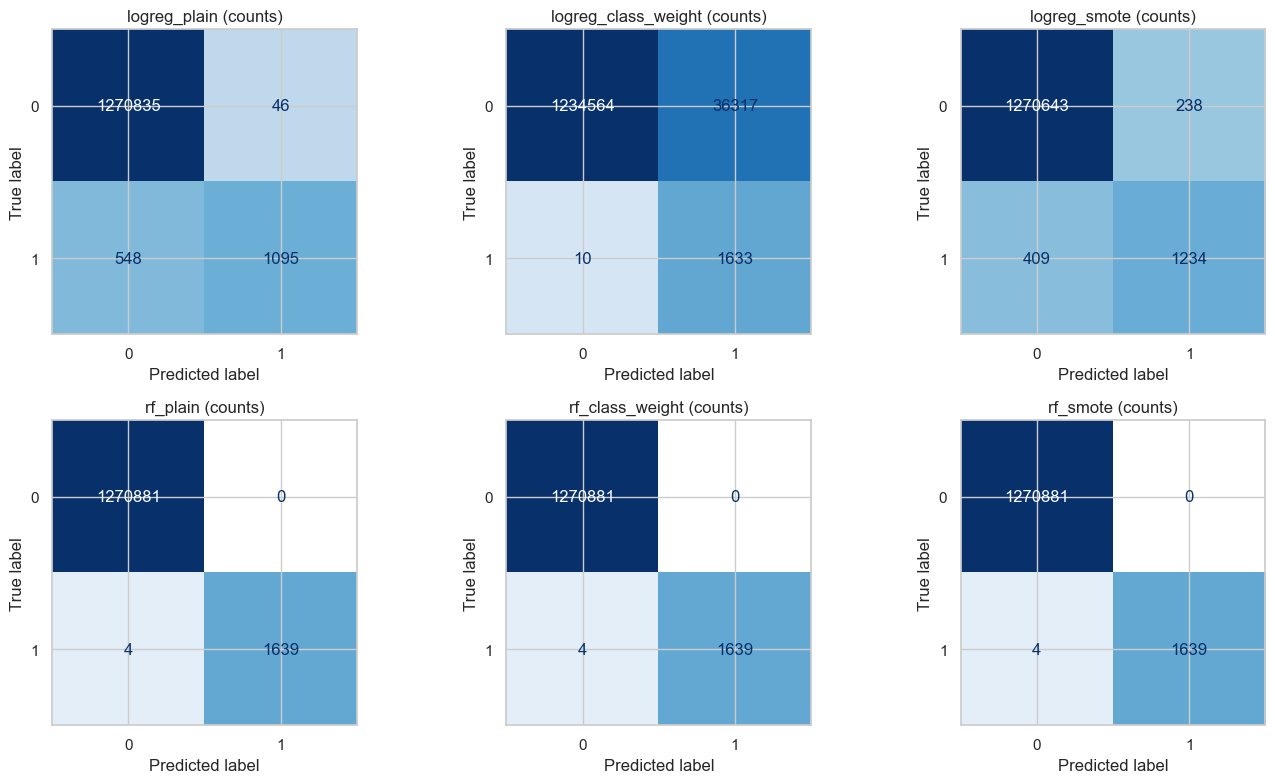

In [53]:
# Plot confusion matrices using raw counts with log-scaled colors for better readability under class imbalance.
from matplotlib.colors import LogNorm

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for ax, exp_name in zip(axes, experiments.keys()):
    cm = confusion_matrices[exp_name]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format="d",
        im_kw={"norm": LogNorm(vmin=1, vmax=max(1, cm.max()))},
    )
    ax.set_title(f"{exp_name} (counts)")
plt.tight_layout()
plt.show()


### 12.5b Confusion matrices (row-normalized)

Row-normalized confusion matrices convert each true-class row to proportions (sum = 1). This is important in imbalanced fraud data because it makes minority-class behavior (fraud recall and miss rate) directly comparable across models, independent of raw class sizes.

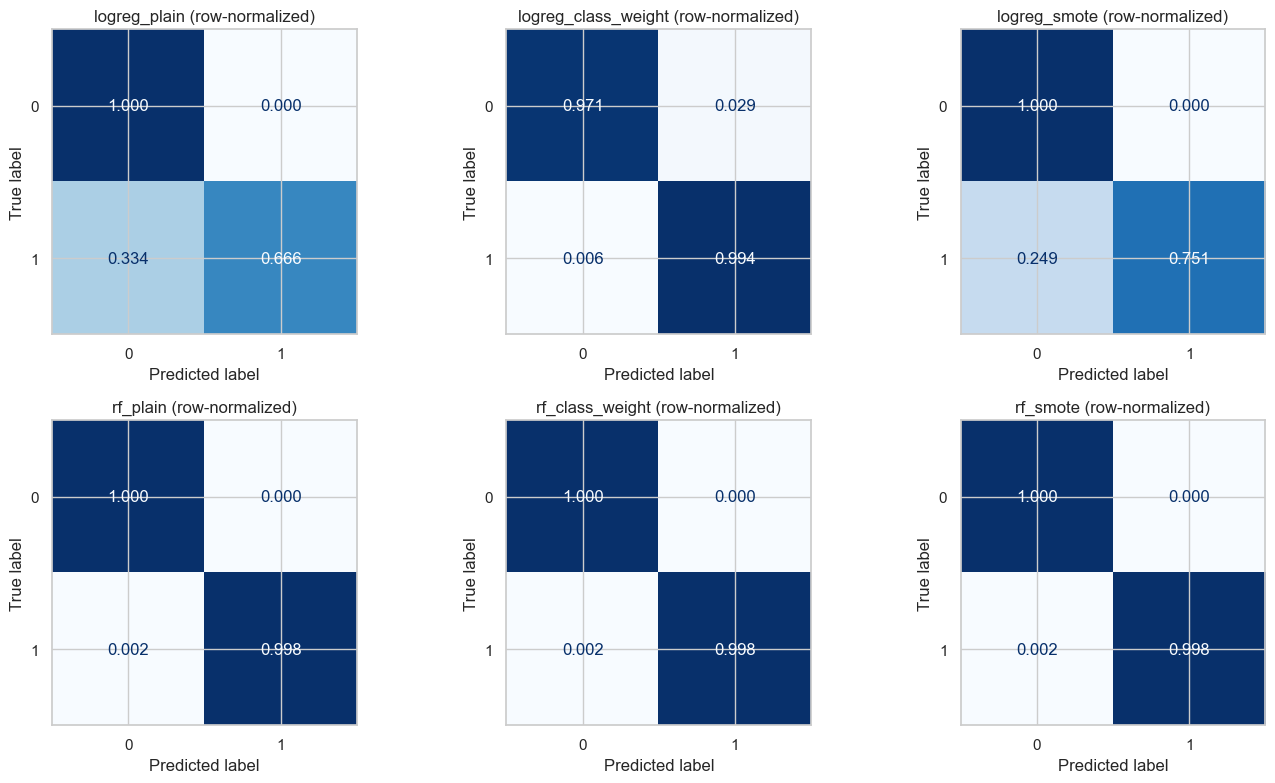

In [54]:
# Plot row-normalized confusion matrices to compare per-class error rates across models.
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for ax, exp_name in zip(axes, experiments.keys()):
    cm = confusion_matrices[exp_name]
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format=".3f")
    ax.set_title(f"{exp_name} (row-normalized)")
plt.tight_layout()
plt.show()


### 12.6 Clean visual comparisons

We use compact, less-colorful visuals focused on the most important fraud metrics (Recall, Precision, PR-AUC).

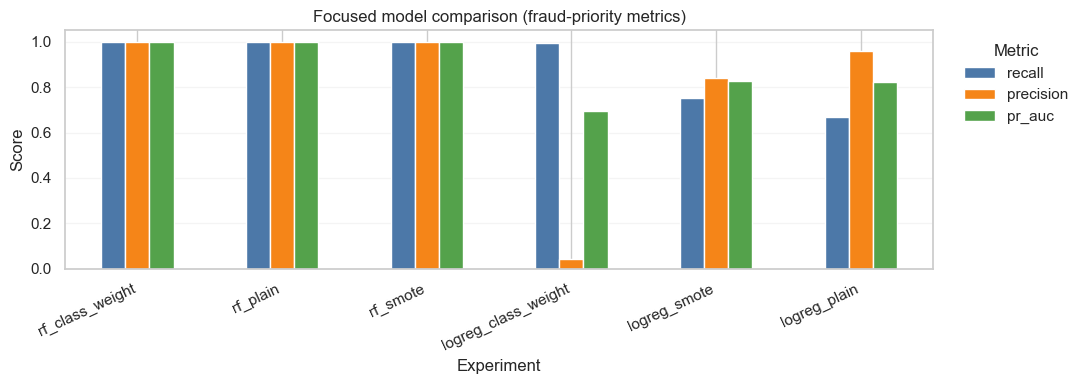

In [48]:
# Plot a clean focused comparison for Recall, Precision, and PR-AUC across experiments.
focus_cols = ["recall", "precision", "pr_auc"]
clean_plot_df = comparison_table[["experiment"] + focus_cols].set_index("experiment")
ax = clean_plot_df.plot(kind="bar", figsize=(11, 4), color=["#4C78A8", "#F58518", "#54A24B"])
ax.set_title("Focused model comparison (fraud-priority metrics)")
ax.set_ylabel("Score")
ax.set_xlabel("Experiment")
ax.grid(axis="y", alpha=0.2)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False, title="Metric")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


### 12.6b ROC and Precision-Recall curves (clean)

These curves use model probability scores on the same untouched test set. PR curves are especially informative under extreme imbalance.

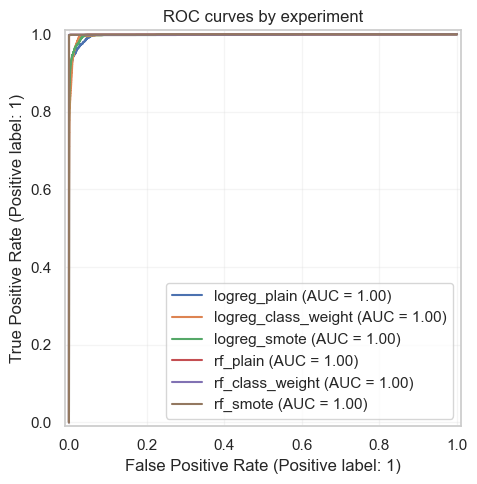

In [49]:
# Plot ROC curves for all six experiments using predicted probabilities on the common test set.
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
fig, ax = plt.subplots(figsize=(7, 5))
for exp_name in experiments.keys():
    y_score = pred_store[exp_name]["y_score"]
    RocCurveDisplay.from_predictions(y_test, y_score, ax=ax, name=exp_name)
ax.set_title("ROC curves by experiment")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


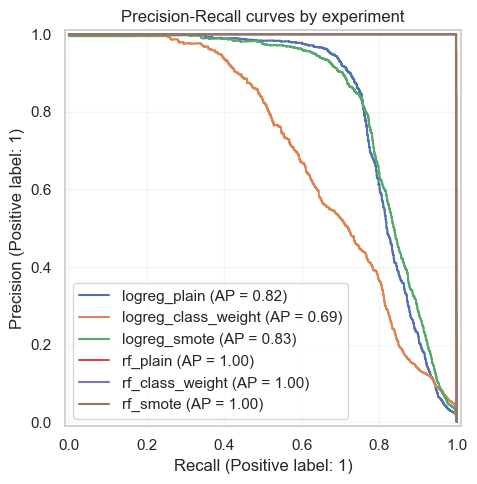

In [50]:
# Plot Precision-Recall curves for all six experiments (key curve type for imbalanced fraud data).
fig, ax = plt.subplots(figsize=(7, 5))
for exp_name in experiments.keys():
    y_score = pred_store[exp_name]["y_score"]
    PrecisionRecallDisplay.from_predictions(y_test, y_score, ax=ax, name=exp_name)
ax.set_title("Precision-Recall curves by experiment")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


### 12.6c Why RF plain/class-weight/SMOTE can look almost identical here

- PaySim fraud is often highly separable with current features (transaction `type`, balance dynamics, engineered deltas/flags).
- Random Forest is already robust on this feature space, so extra imbalance handling may not shift predictions much.
- SMOTE here is intentionally capped in fast mode, so it may have limited additional effect.
- This does **not** mean SMOTE is useless universally; it means marginal benefit is small for RF in this current setup.

### 12.7 Short plain-language summary (which model works better)

This auto-summary follows project priority: **Recall -> Precision -> PR-AUC -> Confusion matrix -> F1 -> ROC-AUC**.

In [51]:
# Print concise answers: class-weight impact, SMOTE impact, best tradeoff, and next-step recommendation.
tbl = comparison_table.copy()

def pick(metric):
    i = tbl[metric].idxmax()
    return tbl.loc[i, "experiment"], float(tbl.loc[i, metric])

best_recall = pick("recall")
best_precision = pick("precision")
best_pr_auc = pick("pr_auc")

def row(exp):
    return tbl.loc[tbl["experiment"] == exp].iloc[0]

lr_p, lr_w, lr_s = row("logreg_plain"), row("logreg_class_weight"), row("logreg_smote")
rf_p, rf_w, rf_s = row("rf_plain"), row("rf_class_weight"), row("rf_smote")

print("Best recall:", best_recall[0], f"({best_recall[1]:.4f})")
print("Best precision:", best_precision[0], f"({best_precision[1]:.4f})")
print("Best PR-AUC:", best_pr_auc[0], f"({best_pr_auc[1]:.4f})")
print()
print("Did class weights improve recall over plain?")
print("- Logistic Regression:", lr_w["recall"] > lr_p["recall"], "|", round(float(lr_p["recall"]),4), "->", round(float(lr_w["recall"]),4))
print("- Random Forest:", rf_w["recall"] > rf_p["recall"], "|", round(float(rf_p["recall"]),4), "->", round(float(rf_w["recall"]),4))
print()
print("Did SMOTE improve recall over plain?")
print("- Logistic Regression:", lr_s["recall"] > lr_p["recall"], "|", round(float(lr_p["recall"]),4), "->", round(float(lr_s["recall"]),4))
print("- Random Forest:", rf_s["recall"] > rf_p["recall"], "|", round(float(rf_p["recall"]),4), "->", round(float(rf_s["recall"]),4))
print()
print("Recommendation for next stage:")
print("- Move forward with one high-recall model and one best precision-PR-AUC tradeoff model.")
print("- Next, tune decision threshold using business cost of false negatives vs false positives.")


Best recall: rf_class_weight (0.9976)
Best precision: rf_class_weight (1.0000)
Best PR-AUC: rf_class_weight (0.9985)

Did class weights improve recall over plain?
- Logistic Regression: True | 0.6665 -> 0.9939
- Random Forest: False | 0.9976 -> 0.9976

Did SMOTE improve recall over plain?
- Logistic Regression: True | 0.6665 -> 0.7511
- Random Forest: False | 0.9976 -> 0.9976

Recommendation for next stage:
- Move forward with one high-recall model and one best precision-PR-AUC tradeoff model.
- Next, tune decision threshold using business cost of false negatives vs false positives.
